<a href="https://colab.research.google.com/github/paulinepiccio/cinema-and-war/blob/main/notebooks/04_analysis_and_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 13

DATA_URL = "https://raw.githubusercontent.com/paulinepiccio/cinema-and-war/main/data/processed/war_movies_classified.csv"
CONFLICTS_URL = "https://raw.githubusercontent.com/paulinepiccio/cinema-and-war/refs/heads/main/data/conflits.csv"

df = pd.read_csv(DATA_URL)
conflicts = pd.read_csv(CONFLICTS_URL)

df_classified = df[df['matched_conflict'].notna()].copy()

print(f"Total films loaded: {df.shape[0]}")
print(f"Classified films: {df_classified.shape[0]}")
print(f"Unique conflicts: {df_classified['matched_conflict'].nunique()}")

print(f"Classified films per country:")
print(df_classified['primary_country'].value_counts())

Total films loaded: 2343
Classified films: 1445
Unique conflicts: 26
Classified films per country:
primary_country
US    649
GB    254
RU    208
FR    167
DE    105
JP     62
Name: count, dtype: int64


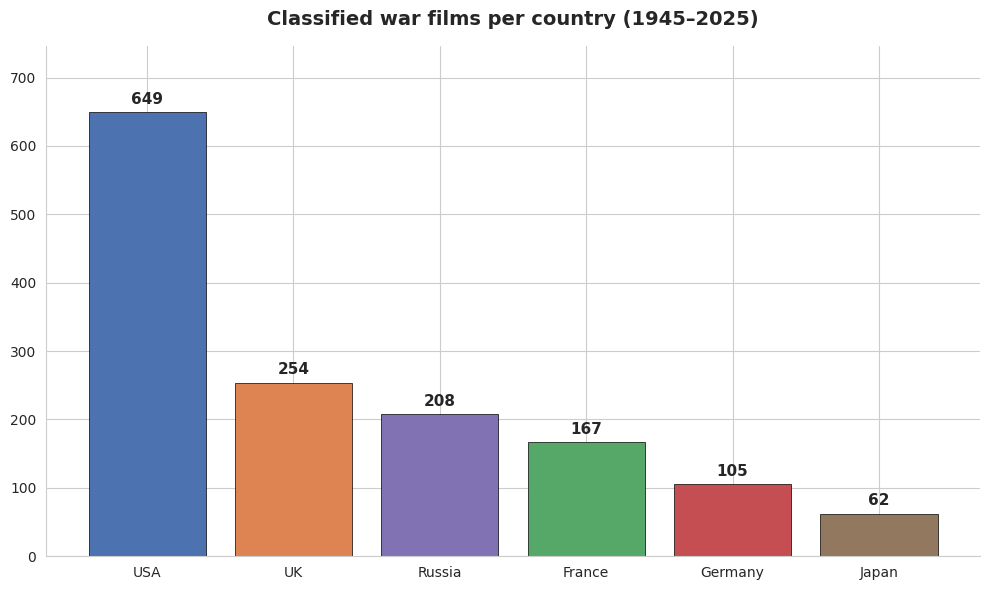

Country share of classified films:
   USA: 649 films (44.9%)
   UK: 254 films (17.6%)
   Russia: 208 films (14.4%)
   France: 167 films (11.6%)
   Germany: 105 films (7.3%)
   Japan: 62 films (4.3%)


In [3]:
# Volume of classified war films per country
country_counts = df_classified['primary_country'].value_counts()

# Map country codes to readable names for display
COUNTRY_NAMES = {
    'US': 'USA',
    'GB': 'UK',
    'FR': 'France',
    'DE': 'Germany',
    'RU': 'Russia',
    'JP': 'Japan'
}

# Distinct categorical colors (Seaborn-inspired palette)
COUNTRY_COLORS = {
    'US': '#4C72B0',  # blue
    'GB': '#DD8452',  # orange
    'FR': '#55A868',  # green
    'DE': '#C44E52',  # red
    'RU': '#8172B3',  # purple
    'JP': '#937860',  # brown
}

fig, ax = plt.subplots(figsize=(10, 6))

countries = country_counts.index.tolist()
values = country_counts.values
labels = [COUNTRY_NAMES.get(c, c) for c in countries]
colors = [COUNTRY_COLORS.get(c, '#999') for c in countries]

bars = ax.bar(labels, values, color=colors, edgecolor='black', linewidth=0.5)

for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 8,
            f'{value}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Classified war films per country (1945–2025)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, max(values) * 1.15)

# Clean spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Print percentages
total = country_counts.sum()
print("Country share of classified films:")
for country, count in country_counts.items():
    pct = count / total * 100
    print(f"   {COUNTRY_NAMES.get(country, country)}: {count} films ({pct:.1f}%)")

In [4]:
import plotly.graph_objects as go

df_classified['decade'] = (df_classified['release_year'] // 10 * 10).astype(int)
df_classified_filtered = df_classified[(df_classified['decade'] >= 1940) & (df_classified['decade'] <= 2020)].copy()
decade_country = df_classified_filtered.groupby(['decade', 'primary_country']).size().unstack(fill_value=0)
all_decades = range(1940, 2030, 10)
decade_country = decade_country.reindex(all_decades, fill_value=0)
if 'country_counts' in locals():
    country_order = country_counts.index.tolist()
else:
    country_order = decade_country.columns.tolist()

decade_country = decade_country.reindex(columns=country_order, fill_value=0)

decade_country_pct = decade_country.div(decade_country.sum(axis=0), axis=1) * 100


fig = go.Figure()

for country in country_order:
    fig.add_trace(go.Scatter(
        x=[f"{int(d)}s" for d in decade_country_pct.index],
        y=decade_country_pct[country],
        mode='lines+markers',
        name=COUNTRY_NAMES[country],
        line=dict(color=COUNTRY_COLORS[country], width=2.5),
        marker=dict(size=8),
        hovertemplate=(
            f'<b>{COUNTRY_NAMES[country]}</b><br>'
            'Decade: %{x}<br>'
            'Share: %{y:.1f}%<br>'
            '<extra></extra>'
        )
    ))

fig.update_layout(
    title=dict(
        text='Temporal distribution of war cinema (% within each country)',
        font=dict(size=15, color='black'),
        x=0.5
    ),
    xaxis_title='Decade',
    yaxis_title="% of country's total war films",
    width=1100,
    height=600,
    template='plotly_white',
    hovermode='x unified',  # show all countries values when hovering a decade
    legend=dict(
        orientation='v',
        yanchor='top',
        y=1,
        xanchor='left',
        x=1.02
    )
)

# Add range slider at the bottom for zooming on specific periods
fig.update_xaxes(rangeslider_visible=True)

fig.show()

# Print the underlying data for reference
print("Decade share per country (% of country's total films):")
print(decade_country_pct.round(1).to_string())

Decade share per country (% of country's total films):
primary_country    US    GB    RU    FR    DE    JP
decade                                             
1940              6.2   4.3   5.8   4.2   1.0   0.0
1950             14.3  18.9   6.2   4.8  15.2  11.3
1960             11.7  12.6  21.6  15.6   9.5  14.5
1970              6.3   7.5  17.3   7.2   8.6   6.5
1980             12.9   7.5  12.0  11.4   5.7  16.1
1990              7.9   5.1   5.3  10.2   8.6   4.8
2000             12.3  14.2  10.1  13.2  14.3  14.5
2010             18.5  19.3  15.9  22.2  22.9  24.2
2020              9.9  10.6   5.8  11.4  14.3   8.1


In [5]:
# Build a country × conflict matrix
heatmap_data = df_classified.groupby(['matched_conflict', 'primary_country']).size().unstack(fill_value=0)

heatmap_data = heatmap_data.reindex(columns=country_order, fill_value=0)

heatmap_data['_total'] = heatmap_data.sum(axis=1)
heatmap_data = heatmap_data.sort_values('_total', ascending=False).drop(columns='_total')

print(f"Heatmap matrix: {heatmap_data.shape[0]} conflicts × {heatmap_data.shape[1]} countries\n")
print(heatmap_data.to_string())

Heatmap matrix: 26 conflicts × 6 countries

primary_country             US   GB   RU   FR  DE  JP
matched_conflict                                     
World War II               428  213  187  134  89  59
Vietnam War                 91    6    0    7   2   1
War in Afghanistan          38    6    7    7   2   0
Iraq War                    23    5    0    1   2   0
Korean War                  27    2    0    0   0   1
Cold War                    11    3    3    1   6   0
Bosnian War                  4    3    0    4   1   1
Algerian War                 1    0    0    9   0   0
Gulf War                     8    1    0    0   1   0
First Chechen War            1    0    8    0   0   0
Russo-Ukrainian War          3    0    1    2   0   0
Syrian Civil War             2    2    0    0   1   0
Falklands War                1    4    0    0   0   0
Northern Ireland Troubles    1    3    0    0   0   0
Soviet-Afghan War            3    0    1    0   0   0
Rwandan Genocide             2    0   

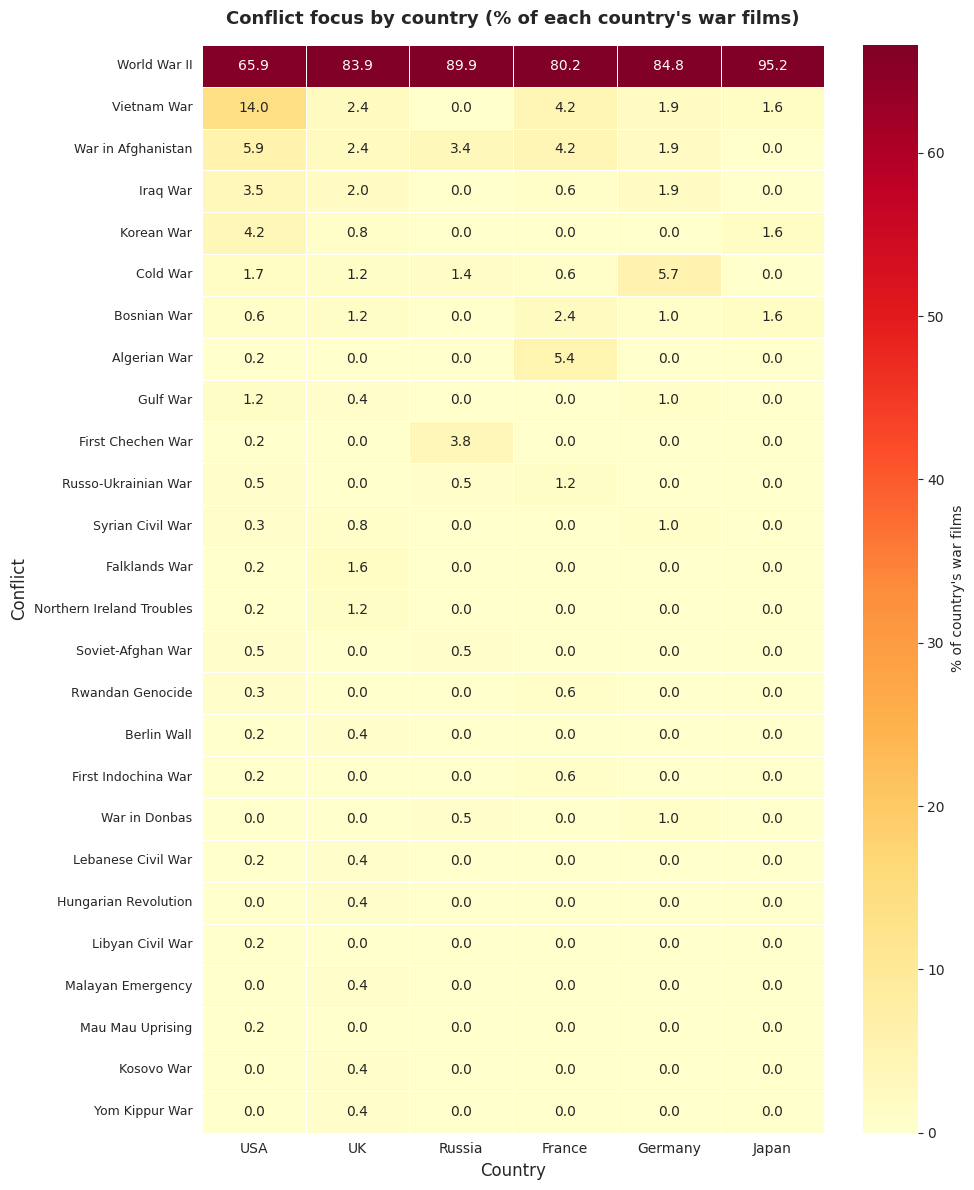

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

primary_country              US    GB    RU    FR    DE    JP
matched_conflict                                             
World War II               65.9  83.9  89.9  80.2  84.8  95.2
Vietnam War                14.0   2.4   0.0   4.2   1.9   1.6
War in Afghanistan          5.9   2.4   3.4   4.2   1.9   0.0
Iraq War                    3.5   2.0   0.0   0.6   1.9   0.0
Korean War                  4.2   0.8   0.0   0.0   0.0   1.6
Cold War                    1.7   1.2   1.4   0.6   5.7   0.0
Bosnian War                 0.6   1.2   0.0   2.4   1.0   1.6
Algerian War                0.2   0.0   0.0   5.4   0.0   0.0
Gulf War                    1.2   0.4   0.0   0.0   1.0   0.0
First Chechen War           0.2   0.0   3.8   0.0   0.0   0.0
Russo-Ukrainian War         0.5   0.0   0.5   1.2   0.0   0.0
Syrian Civil War            0.3   0.8   0.0   0.0   1.0   0.0
Falklands War               0.2   1.6   0.0   0.0   0.0   0.0
Northern Ireland Troubles   0.2   1.2   0.0   0.0   0.0   0.0
Soviet-A

In [9]:
heatmap_pct = heatmap_data.div(heatmap_data.sum(axis=0), axis=1) * 100

fig, ax = plt.subplots(figsize=(10, 12))

sns.heatmap(
    heatmap_pct,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    cbar_kws={'label': "% of country's war films"},
    linewidths=0.5,
    linecolor='white',
    vmin=0,
    vmax=heatmap_pct.values.max() * 0.7,
)

ax.set_xticklabels([COUNTRY_NAMES[c] for c in heatmap_pct.columns], rotation=0, fontsize=10)
ax.set_yticklabels(heatmap_pct.index, rotation=0, fontsize=9)

ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Conflict', fontsize=12)
ax.set_title("Conflict focus by country (% of each country's war films)",
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()

plt.savefig(
    '/content/03_heatmap_conflict_country.png',
    dpi=200,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()

from google.colab import files
files.download('03_heatmap_conflict_country.png')

plt.show()

print(heatmap_pct.round(1).to_string())

In [10]:
conflict_countries = {}
for _, row in conflicts.iterrows():
    countries_str = row['involved_countries']
    if pd.notna(countries_str):
        country_set = set(c.strip() for c in countries_str.split(','))
        conflict_countries[row['conflict']] = country_set

def classify_narration(row):
    conflict = row['matched_conflict']
    primary = row['primary_country']
    if conflict not in conflict_countries:
        return 'unknown'
    if primary in conflict_countries[conflict]:
        return 'self'
    else:
        return 'other'

df_classified['narration_type'] = df_classified.apply(classify_narration, axis=1)

# Overall stats
print(df_classified['narration_type'].value_counts())
print(f"Overall self-narration rate: {(df_classified['narration_type'] == 'self').mean()*100:.1f}%")

narration_type
self     1406
other      39
Name: count, dtype: int64
Overall self-narration rate: 97.3%


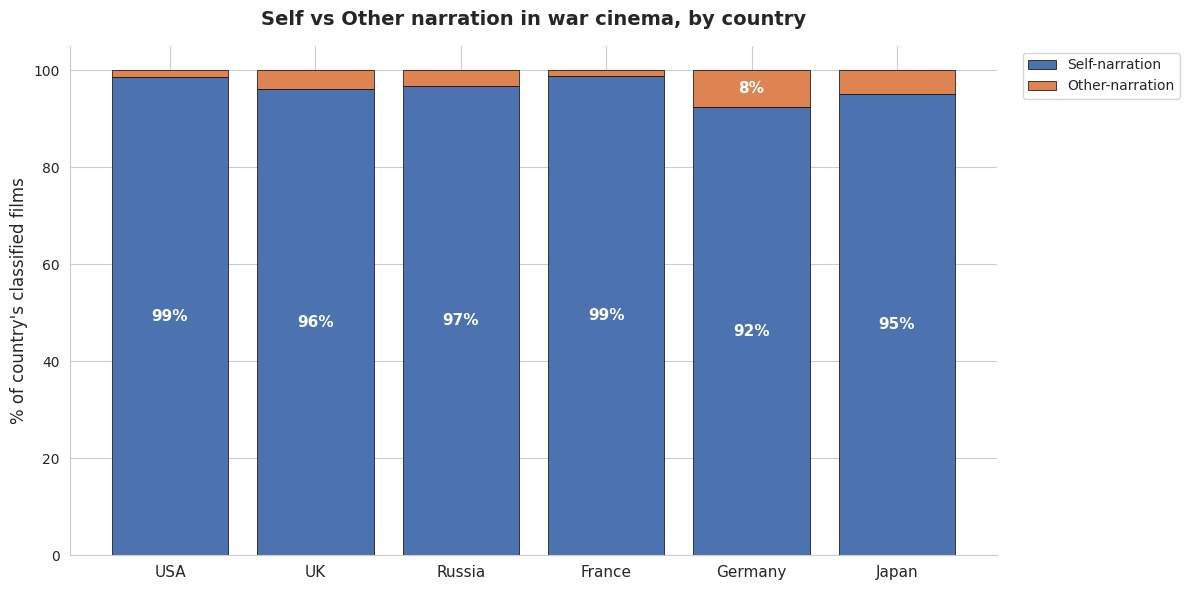

Self vs Other narration per country (%):
narration_type   other  self  unknown
primary_country                      
US                 1.4  98.6        0
GB                 3.9  96.1        0
RU                 3.4  96.6        0
FR                 1.2  98.8        0
DE                 7.6  92.4        0
JP                 4.8  95.2        0


In [11]:
narration_by_country = pd.crosstab(
    df_classified['primary_country'],
    df_classified['narration_type'],
    normalize='index'
) * 100

narration_by_country = narration_by_country.reindex(country_order)

for col in ['self', 'other', 'unknown']:
    if col not in narration_by_country.columns:
        narration_by_country[col] = 0

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(narration_by_country))
self_vals = narration_by_country['self'].values
other_vals = narration_by_country['other'].values

ax.bar(x, self_vals, color='#4C72B0', edgecolor='black', linewidth=0.5, label='Self-narration')
ax.bar(x, other_vals, bottom=self_vals, color='#DD8452', edgecolor='black', linewidth=0.5, label='Other-narration')

for i in range(len(narration_by_country)):
    ax.text(x[i], self_vals[i]/2, f"{self_vals[i]:.0f}%",
            ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    if other_vals[i] > 5:
        ax.text(x[i], self_vals[i] + other_vals[i]/2, f"{other_vals[i]:.0f}%",
                ha='center', va='center', fontsize=11, fontweight='bold', color='white')

ax.set_xticks(x)
ax.set_xticklabels([COUNTRY_NAMES[c] for c in narration_by_country.index], fontsize=11)
ax.set_ylabel("% of country's classified films", fontsize=12)
ax.set_title('Self vs Other narration in war cinema, by country',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, 105)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True, fontsize=10)

plt.tight_layout()
plt.show()

print("Self vs Other narration per country (%):")
print(narration_by_country.round(1).to_string())

Films excluding WWII: 335 (out of 1445)


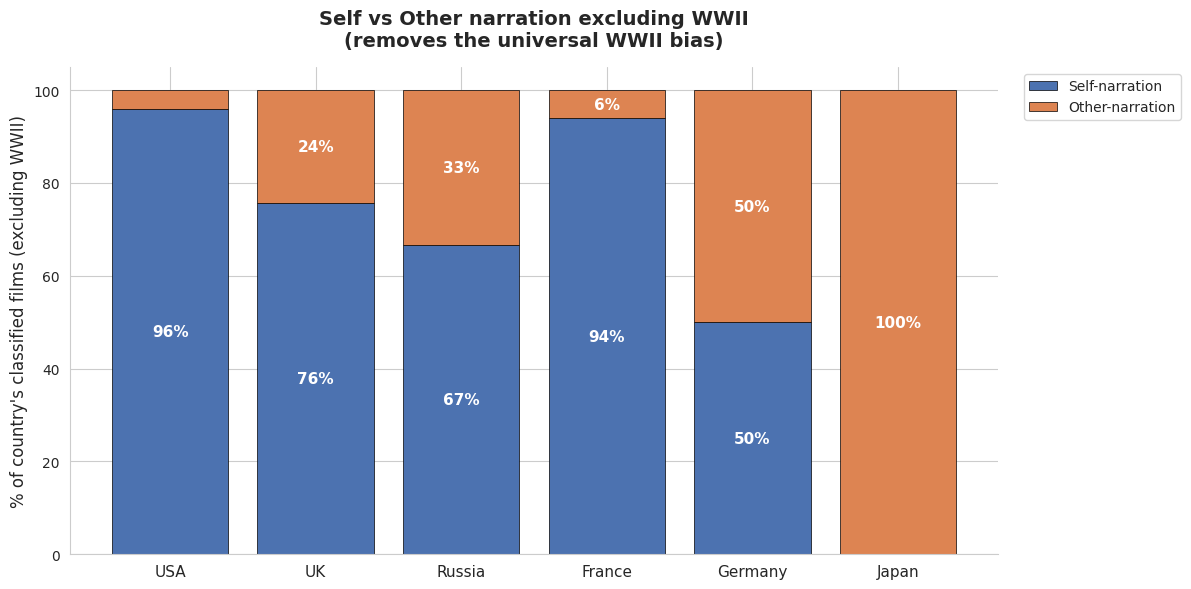

Self vs Other excluding WWII (%):
narration_type   other  self  unknown
primary_country                      
US                 4.1  95.9        0
GB                24.4  75.6        0
RU                33.3  66.7        0
FR                 6.1  93.9        0
DE                50.0  50.0        0
JP               100.0   0.0        0


In [12]:
# Re-run the analysis excluding WWII, which dominates every country and mechanically inflates self-narration rates

df_no_wwii = df_classified[df_classified['matched_conflict'] != 'World War II'].copy()

print(f"Films excluding WWII: {len(df_no_wwii)} (out of {len(df_classified)})")

narration_no_wwii = pd.crosstab(
    df_no_wwii['primary_country'],
    df_no_wwii['narration_type'],
    normalize='index'
) * 100

narration_no_wwii = narration_no_wwii.reindex(country_order)

for col in ['self', 'other', 'unknown']:
    if col not in narration_no_wwii.columns:
        narration_no_wwii[col] = 0

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(narration_no_wwii))
self_vals = narration_no_wwii['self'].values
other_vals = narration_no_wwii['other'].values

ax.bar(x, self_vals, color='#4C72B0', edgecolor='black', linewidth=0.5, label='Self-narration')
ax.bar(x, other_vals, bottom=self_vals, color='#DD8452', edgecolor='black', linewidth=0.5, label='Other-narration')

for i in range(len(narration_no_wwii)):
    if self_vals[i] > 5:
        ax.text(x[i], self_vals[i]/2, f"{self_vals[i]:.0f}%",
                ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    if other_vals[i] > 5:
        ax.text(x[i], self_vals[i] + other_vals[i]/2, f"{other_vals[i]:.0f}%",
                ha='center', va='center', fontsize=11, fontweight='bold', color='white')

ax.set_xticks(x)
ax.set_xticklabels([COUNTRY_NAMES[c] for c in narration_no_wwii.index], fontsize=11)
ax.set_ylabel("% of country's classified films (excluding WWII)", fontsize=12)
ax.set_title('Self vs Other narration excluding WWII\n(removes the universal WWII bias)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, 105)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True, fontsize=10)

plt.subplots_adjust(right=0.85)
plt.tight_layout()
plt.show()

print("Self vs Other excluding WWII (%):")
print(narration_no_wwii.round(1).to_string())

In [15]:
print("Top 'other-narration' conflicts per country:")

for country in country_order:
    other_films = df_classified[
        (df_classified['primary_country'] == country) &
        (df_classified['narration_type'] == 'other')
    ]

    if len(other_films) == 0:
        print(f"{COUNTRY_NAMES[country]}: no 'other' conflicts")
        continue

    top_other = other_films['matched_conflict'].value_counts().head(5)
    print(f"{COUNTRY_NAMES[country]} ({len(other_films)} films filming others' conflicts):")
    for conflict, n in top_other.items():
        print(f"  - {conflict}: {n} films")

Top 'other-narration' conflicts per country:
USA (9 films filming others' conflicts):
  - Rwandan Genocide: 2 films
  - First Chechen War: 1 films
  - Northern Ireland Troubles: 1 films
  - Lebanese Civil War: 1 films
  - Mau Mau Uprising: 1 films
UK (10 films filming others' conflicts):
  - Vietnam War: 6 films
  - Berlin Wall: 1 films
  - Lebanese Civil War: 1 films
  - Hungarian Revolution: 1 films
  - Yom Kippur War: 1 films
Russia (7 films filming others' conflicts):
  - War in Afghanistan: 7 films
France (2 films filming others' conflicts):
  - Cold War: 1 films
  - Iraq War: 1 films
Germany (8 films filming others' conflicts):
  - Vietnam War: 2 films
  - Iraq War: 2 films
  - Gulf War: 1 films
  - Bosnian War: 1 films
  - Syrian Civil War: 1 films
Japan (3 films filming others' conflicts):
  - Vietnam War: 1 films
  - Korean War: 1 films
  - Bosnian War: 1 films


In [16]:
# Classify each film into one of 3 temporal categories relative to its conflict

conflict_start_years = conflicts.set_index('conflict')['start_year'].to_dict()
conflict_end_years = conflicts.set_index('conflict')['end_year'].to_dict()

def classify_temporal_position(row):
    """
    Classify the film's release timing relative to its matched conflict:
    - 'During': released while the conflict was active (or before it started, rare)
    - 'Aftermath': released within 10 years after the conflict ended
    - 'Long-term memory': released more than 10 years after the conflict ended
    """
    conflict = row['matched_conflict']
    release = row['release_year']

    if conflict not in conflict_end_years:
        return 'unknown'

    start = conflict_start_years[conflict]
    end = conflict_end_years[conflict]

    if release <= end:
        return 'During'
    elif release <= end + 10:
        return 'Aftermath'
    else:
        return 'Long-term memory'

df_classified['temporal_position'] = df_classified.apply(classify_temporal_position, axis=1)

# Overview
print("Temporal position breakdown:")
print(df_classified['temporal_position'].value_counts())

print("Percentages:")
print((df_classified['temporal_position'].value_counts(normalize=True) * 100).round(1))

Temporal position breakdown:
temporal_position
Long-term memory    1077
Aftermath            211
During               157
Name: count, dtype: int64
Percentages:
temporal_position
Long-term memory    74.5
Aftermath           14.6
During              10.9
Name: proportion, dtype: float64


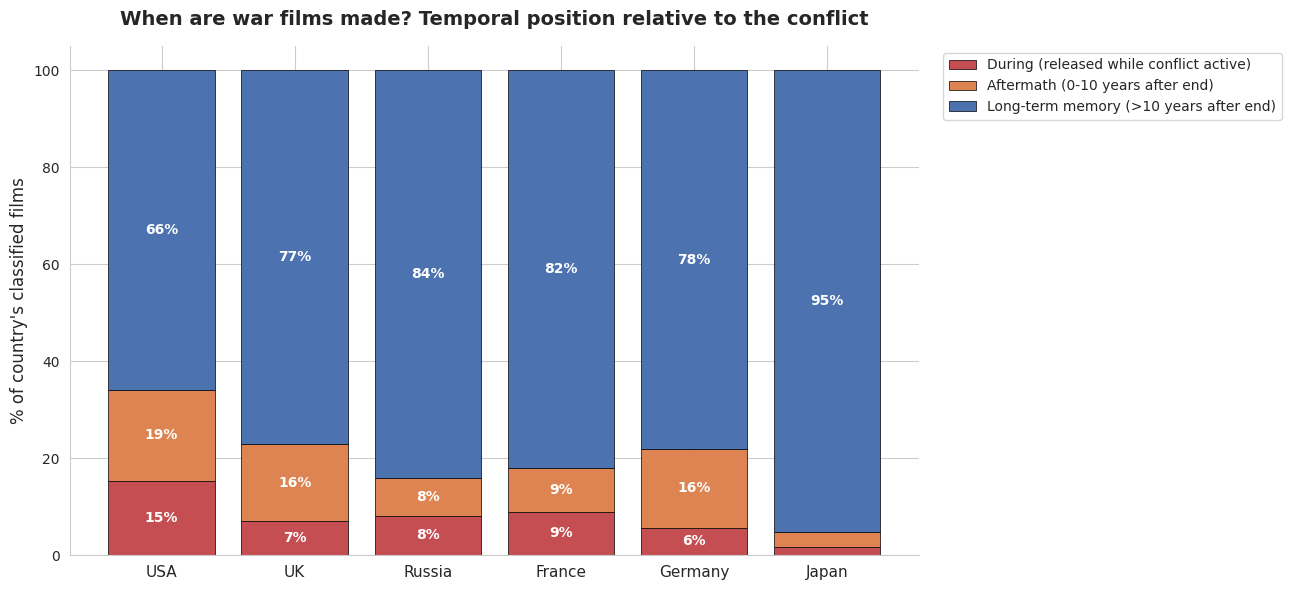

Temporal position per country (%):
temporal_position  During  Aftermath  Long-term memory
primary_country                                       
US                   15.4       18.6              65.9
GB                    7.1       15.7              77.2
RU                    8.2        7.7              84.1
FR                    9.0        9.0              82.0
DE                    5.7       16.2              78.1
JP                    1.6        3.2              95.2


In [17]:
temporal_by_country = pd.crosstab(
    df_classified['primary_country'],
    df_classified['temporal_position'],
    normalize='index'
) * 100

# Reorder columns logically (chronological order of the 3 positions)
temporal_by_country = temporal_by_country.reindex(columns=['During', 'Aftermath', 'Long-term memory'], fill_value=0)
temporal_by_country = temporal_by_country.reindex(country_order)

fig, ax = plt.subplots(figsize=(13, 6))

x = np.arange(len(temporal_by_country))
during = temporal_by_country['During'].values
aftermath = temporal_by_country['Aftermath'].values
longterm = temporal_by_country['Long-term memory'].values

ax.bar(x, during, color='#C44E52', edgecolor='black', linewidth=0.5, label='During (released while conflict active)')
ax.bar(x, aftermath, bottom=during, color='#DD8452', edgecolor='black', linewidth=0.5, label='Aftermath (0-10 years after end)')
ax.bar(x, longterm, bottom=during+aftermath, color='#4C72B0', edgecolor='black', linewidth=0.5, label='Long-term memory (>10 years after end)')

for i in range(len(temporal_by_country)):
    if during[i] > 4:
        ax.text(x[i], during[i]/2, f"{during[i]:.0f}%",
                ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    if aftermath[i] > 4:
        ax.text(x[i], during[i] + aftermath[i]/2, f"{aftermath[i]:.0f}%",
                ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    if longterm[i] > 4:
        ax.text(x[i], during[i] + aftermath[i] + longterm[i]/2, f"{longterm[i]:.0f}%",
                ha='center', va='center', fontsize=10, fontweight='bold', color='white')

ax.set_xticks(x)
ax.set_xticklabels([COUNTRY_NAMES[c] for c in temporal_by_country.index], fontsize=11)
ax.set_ylabel("% of country's classified films", fontsize=12)
ax.set_title('When are war films made? Temporal position relative to the conflict',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, 105)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True, fontsize=10)

plt.subplots_adjust(right=0.7)
plt.tight_layout()
plt.show()

print("Temporal position per country (%):")
print(temporal_by_country.round(1).to_string())

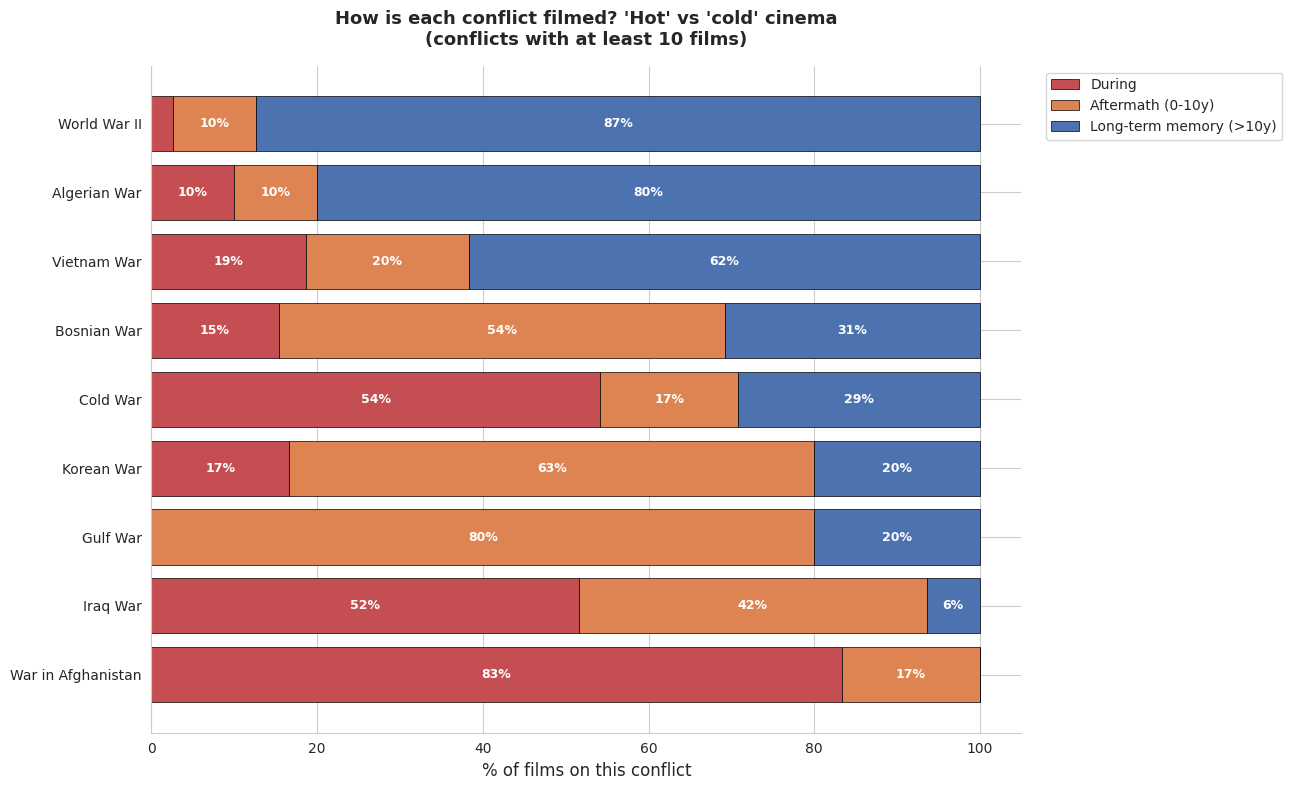

Temporal position per conflict (%):
temporal_position   During  Aftermath  Long-term memory
matched_conflict                                       
War in Afghanistan    83.3       16.7               0.0
Iraq War              51.6       41.9               6.5
Gulf War               0.0       80.0              20.0
Korean War            16.7       63.3              20.0
Cold War              54.2       16.7              29.2
Bosnian War           15.4       53.8              30.8
Vietnam War           18.7       19.6              61.7
Algerian War          10.0       10.0              80.0
World War II           2.6       10.0              87.4


In [18]:
# Same analysis but by conflict instead of by country

top_conflicts = df_classified['matched_conflict'].value_counts()
conflicts_to_plot = top_conflicts[top_conflicts >= 10].index.tolist()

df_plot = df_classified[df_classified['matched_conflict'].isin(conflicts_to_plot)].copy()

temporal_by_conflict = pd.crosstab(
    df_plot['matched_conflict'],
    df_plot['temporal_position'],
    normalize='index'
) * 100

temporal_by_conflict = temporal_by_conflict.reindex(columns=['During', 'Aftermath', 'Long-term memory'], fill_value=0)

temporal_by_conflict = temporal_by_conflict.sort_values('Long-term memory', ascending=True)

fig, ax = plt.subplots(figsize=(13, 8))

y = np.arange(len(temporal_by_conflict))
during = temporal_by_conflict['During'].values
aftermath = temporal_by_conflict['Aftermath'].values
longterm = temporal_by_conflict['Long-term memory'].values

ax.barh(y, during, color='#C44E52', edgecolor='black', linewidth=0.5, label='During')
ax.barh(y, aftermath, left=during, color='#DD8452', edgecolor='black', linewidth=0.5, label='Aftermath (0-10y)')
ax.barh(y, longterm, left=during+aftermath, color='#4C72B0', edgecolor='black', linewidth=0.5, label='Long-term memory (>10y)')

for i in range(len(temporal_by_conflict)):
    if during[i] > 5:
        ax.text(during[i]/2, y[i], f"{during[i]:.0f}%",
                ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    if aftermath[i] > 5:
        ax.text(during[i] + aftermath[i]/2, y[i], f"{aftermath[i]:.0f}%",
                ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    if longterm[i] > 5:
        ax.text(during[i] + aftermath[i] + longterm[i]/2, y[i], f"{longterm[i]:.0f}%",
                ha='center', va='center', fontsize=9, fontweight='bold', color='white')

ax.set_yticks(y)
ax.set_yticklabels(temporal_by_conflict.index, fontsize=10)
ax.set_xlabel("% of films on this conflict", fontsize=12)
ax.set_title("How is each conflict filmed? 'Hot' vs 'cold' cinema\n(conflicts with at least 10 films)",
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(0, 105)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True, fontsize=10)

plt.subplots_adjust(right=0.7)
plt.tight_layout()
plt.show()

print("Temporal position per conflict (%):")
print(temporal_by_conflict.round(1).to_string())

In [19]:
# For each conflict, I compute :
# - Number of distinct producing countries
# - Total number of films
# - Share of films from the dominant country (concentration index)

conflict_metrics = []

for conflict in df_classified['matched_conflict'].unique():
    subset = df_classified[df_classified['matched_conflict'] == conflict]

    n_countries = subset['primary_country'].nunique()
    n_films = len(subset)

    # Concentration : % of films from the country that filmed it the most
    country_counts = subset['primary_country'].value_counts()
    dominant_share = (country_counts.iloc[0] / n_films) * 100
    dominant_country = country_counts.index[0]

    conflict_metrics.append({
        'conflict': conflict,
        'n_countries': n_countries,
        'n_films': n_films,
        'dominant_country': dominant_country,
        'dominant_share': dominant_share
    })

metrics_df = pd.DataFrame(conflict_metrics)

# Sort by number of countries first, then by total films
metrics_df = metrics_df.sort_values(['n_countries', 'n_films'], ascending=[False, False]).reset_index(drop=True)

print("Conflict universality metrics:")
print(metrics_df.to_string(index=False))

Conflict universality metrics:
                 conflict  n_countries  n_films dominant_country  dominant_share
             World War II            6     1110               US       38.558559
              Vietnam War            5      107               US       85.046729
       War in Afghanistan            5       60               US       63.333333
                 Cold War            5       24               US       45.833333
              Bosnian War            5       13               US       30.769231
                 Iraq War            4       31               US       74.193548
               Korean War            3       30               US       90.000000
                 Gulf War            3       10               US       80.000000
      Russo-Ukrainian War            3        6               US       50.000000
         Syrian Civil War            3        5               GB       40.000000
             Algerian War            2       10               FR       90.0000

In [20]:
# I Classify conflicts into 3 categories based on the number of producing countries

def classify_universality(n_countries):
    if n_countries >= 5:
        return 'Universal (5-6 countries)'
    elif n_countries >= 2:
        return 'Shared (2-4 countries)'
    else:
        return 'National (1 country)'

metrics_df['universality'] = metrics_df['n_countries'].apply(classify_universality)

# Counts and percentages
print("Conflict distribution by universality:")
print(metrics_df['universality'].value_counts())

print("Examples in each category:")
for cat in ['Universal (5-6 countries)', 'Shared (2-4 countries)', 'National (1 country)']:
    print(f"\n--- {cat} ---")
    subset = metrics_df[metrics_df['universality'] == cat]
    for _, row in subset.iterrows():
        print(f"  {row['conflict']}: {row['n_films']} films across {row['n_countries']} countries (dominant: {row['dominant_country']} at {row['dominant_share']:.0f}%)")

Conflict distribution by universality:
universality
Shared (2-4 countries)       15
National (1 country)          6
Universal (5-6 countries)     5
Name: count, dtype: int64
Examples in each category:

--- Universal (5-6 countries) ---
  World War II: 1110 films across 6 countries (dominant: US at 39%)
  Vietnam War: 107 films across 5 countries (dominant: US at 85%)
  War in Afghanistan: 60 films across 5 countries (dominant: US at 63%)
  Cold War: 24 films across 5 countries (dominant: US at 46%)
  Bosnian War: 13 films across 5 countries (dominant: US at 31%)

--- Shared (2-4 countries) ---
  Iraq War: 31 films across 4 countries (dominant: US at 74%)
  Korean War: 30 films across 3 countries (dominant: US at 90%)
  Gulf War: 10 films across 3 countries (dominant: US at 80%)
  Russo-Ukrainian War: 6 films across 3 countries (dominant: US at 50%)
  Syrian Civil War: 5 films across 3 countries (dominant: GB at 40%)
  Algerian War: 10 films across 2 countries (dominant: FR at 90%)
  Fi

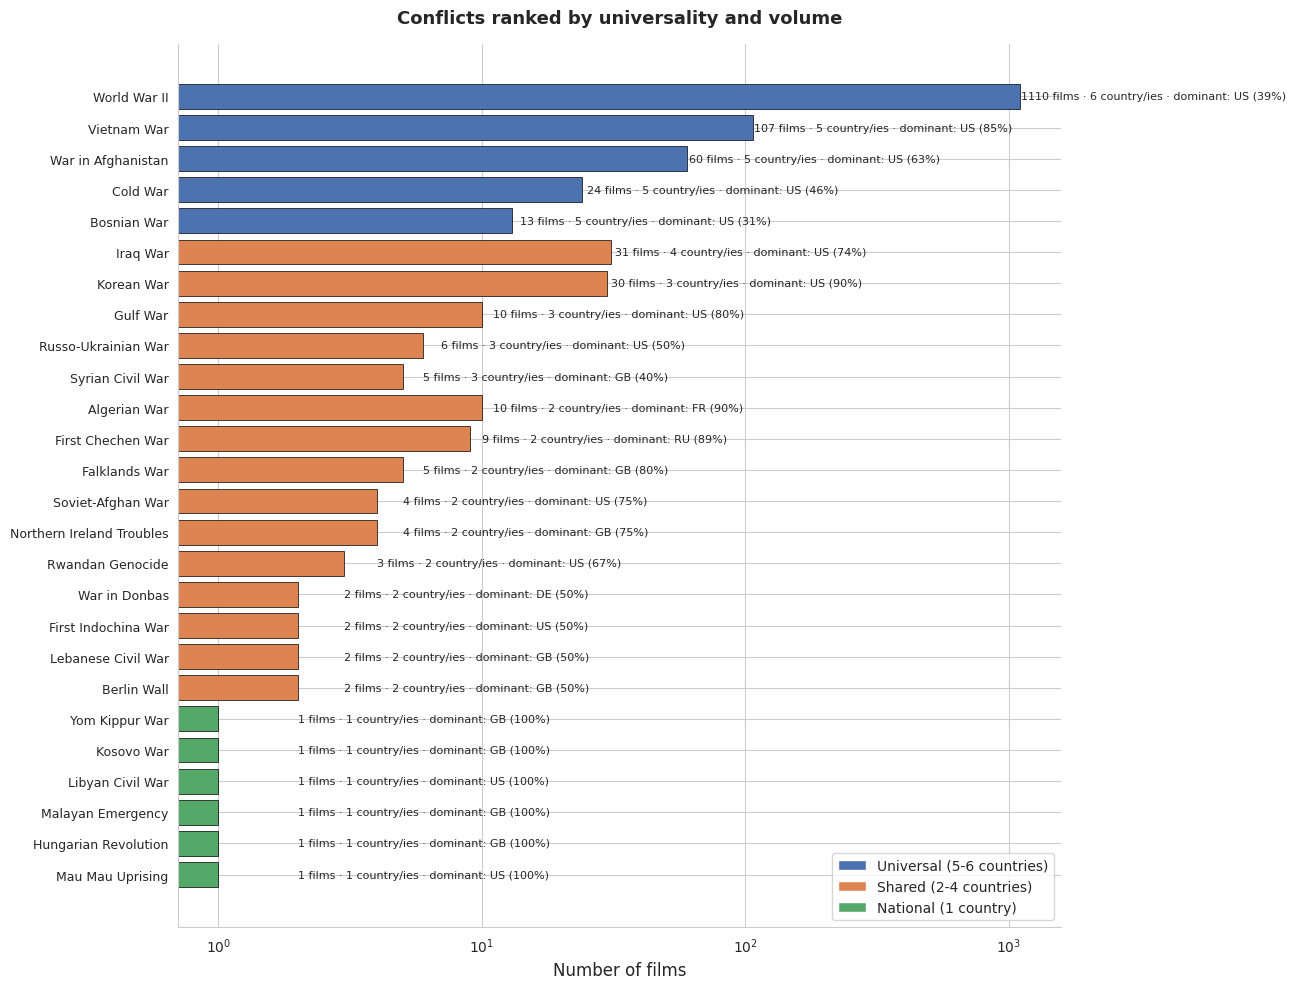

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
# Horizontal bar chart showing all conflicts, grouped by universality

fig, ax = plt.subplots(figsize=(13, 10))

universality_colors = {
    'Universal (5-6 countries)': '#4C72B0',  # Blue
    'Shared (2-4 countries)': '#DD8452',     # Orange
    'National (1 country)': '#55A868'        # Green
}

display_order = metrics_df.sort_values(
    ['n_countries', 'n_films'],
    ascending=[True, True]
).reset_index(drop=True)

y_positions = np.arange(len(display_order))
colors = [universality_colors[u] for u in display_order['universality']]

bars = ax.barh(y_positions, display_order['n_films'], color=colors, edgecolor='black', linewidth=0.5)

for i, row in display_order.iterrows():
    ax.text(
        row['n_films'] + 1,
        i,
        f"{row['n_films']} films · {row['n_countries']} country/ies · dominant: {row['dominant_country']} ({row['dominant_share']:.0f}%)",
        va='center',
        fontsize=8
    )

ax.set_yticks(y_positions)
ax.set_yticklabels(display_order['conflict'], fontsize=9)
ax.set_xlabel('Number of films', fontsize=12)
ax.set_title('Conflicts ranked by universality and volume',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xscale('log')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=universality_colors[u], label=u)
    for u in ['Universal (5-6 countries)', 'Shared (2-4 countries)', 'National (1 country)']
]
ax.legend(handles=legend_elements, loc='lower right', frameon=True, fontsize=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(
    '/content/06_universality_ranking.png',
    dpi=200,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

from google.colab import files
files.download('06_universality_ranking.png')

###Universality insights

**Most conflicts remain national or sub-regional cinematic subjects.**

Of the 26 conflicts in our dataset :
- Only **5 conflicts (19%) are universally filmed** by 5-6 countries
- 15 conflicts (58%) are shared by 2-4 countries
- 6 conflicts (23%) are filmed by a single country

**WWII is the only truly universal conflict.**

WWII alone is filmed by all 6 countries, with relatively balanced
contributions (US 39%, others 7-19%). It is the **only conflict** in
our dataset that genuinely transcends national borders : every country
in our sample has built its own cinematic relationship with this war.

**The other "universal" conflicts are American hegemonies in disguise.**

Vietnam War, War in Afghanistan, Cold War, and Bosnian War are
technically filmed by 5 countries, but the production is heavily
US-dominated :
- Vietnam War : 85% American films
- War in Afghanistan : 63% American  
- Cold War : 46% American

What looks "universal" is often "American with token participation
from other countries". Hollywood's cultural reach is so wide that
when a conflict involves the US, films appear globally, but **led
by US production**.

**True national signatures : 4 conflicts dominated by a single
non-American country.**

These are the cinematic "property" of one nation:
- **Algerian War**: 90% French. France has near-exclusive
  ownership of this colonial memory
- **First Chechen War**: 89% Russian. Only Russia has chosen
  to film this brutal post-Soviet conflict
- **Falklands War**: 80% British. The South Atlantic conflict
  remains an explicitly British subject
- **Northern Ireland Troubles**: 75% British. Also a British
  specialty, with limited foreign interest

**Telling silences :**

- The **Mau Mau Uprising** (Kenya, 1952-60), a British colonial
  conflict, is filmed only **by the USA** (a single film), never
  by the UK itself. This represents a clear blind spot in British
  cinema on its own colonial history.

- The **Malayan Emergency** and **Hungarian Revolution** each have
  only one film (UK), highlighting how marginal these mid-20th-century
  events have become cinematically.

- **6 conflicts** (Mau Mau, Hungarian, Malayan, Libyan, Kosovo,
  Yom Kippur) appear only once in our entire dataset. They are
  cinematically "frozen" : barely processed by any national cinema.

**A surprising case : Soviet-Afghan War, filmed more by Americans
than by Russians.**

The 1979-89 Soviet invasion of Afghanistan generated 4 films in our
dataset : 3 American (*Rambo III*, *The Beast*, and *Afgan : The Soviet
Experience*) and 1 Russian (*Peshawar Waltz*). Hollywood has thus
engaged more with the Soviet Afghan war than Russian cinema itself,  
a reversal that reflects the Cold War framing of this conflict as a
US-perspective story (mujahideen as freedom fighters, Soviet defeat
as Cold War triumph).

**The big takeaway :**

> Despite the appearance of universality, war cinema is a
> **fragmented landscape**. Only WWII speaks across all six
> countries as a shared cinematic language. The other "universal"
> conflicts are American-dominated narratives that other countries
> occasionally contribute to. Beyond that, each country guards its
> own conflicts : France owns Algeria, Russia owns Chechnya, the UK
> owns the Falklands. And many wars (especially colonial conflicts)
> remain cinematically untold, even by the countries that fought
> them.